# 🎭 Face Detection System - Complete Guide
## Combining Haar Cascade, HOG/SVM, and Face Landmarks

In this notebook, we'll build a complete face detection system that:
- ✅ Detects faces using **Haar Cascade Classifiers**
- ✅ Enhances detection with **HOG + SVM** (Histogram of Oriented Gradients + Support Vector Machine)
- ✅ Detects **facial landmarks** using dlib
- ✅ Shows **real-time webcam demo** with overlays
- ✅ Compares different methods

**What you'll learn:** How different face detection techniques work and when to use each!

## Section 1: Understanding Face Detection Methods

### 🏛️ Method 1: Haar Cascade Classifier
- **What it is:** Uses patterns (edges, lines) to identify faces quickly
- **How it works:** Scans the image at multiple scales looking for face-like patterns
- **Pros:** ⚡ Very fast, works well for frontal faces
- **Cons:** ❌ Sensitive to lighting, angles, and expressions

### 🎯 Method 2: HOG + SVM
- **What it is:** Combines Histogram of Oriented Gradients with Support Vector Machine
- **How it works:** Extracts features from edges, then uses machine learning to classify
- **Pros:** 📊 More accurate than Haar Cascade
- **Cons:** 🐢 Slower than Haar Cascade

### 😊 Method 3: Facial Landmarks (dlib)
- **What it is:** Detects 68 specific points on the face (eyes, nose, mouth, etc.)
- **How it works:** Uses deep learning to find exact facial features
- **Pros:** 🎨 Detailed feature information
- **Cons:** 🔧 Requires good initial face detection

## ⚡ Quick Start Guide

### If you got a dlib build error:

**Don't panic!** This is expected on Windows. Your options:

1. **Continue anyway** ✅ (Recommended for now)
   - Haar Cascade detection works
   - HOG detection works
   - Just skip the landmarks section
   
2. **Fix it now** (Choose one):
   - Option A: `pip install mediapipe` (easiest, works great)
   - Option B: Install Visual Studio C++ (complex)
   - Option C: Find a pre-built dlib wheel online

### What you can do right now:
✅ **Haar Cascade detection** - Run Section 3 demos
✅ **HOG detection** - Run Section 4 demos  
✅ **Real-time webcam** - Works with Haar/HOG
❌ **Landmarks** - Skip if dlib not installed

**You'll still learn all the key concepts!** Don't get blocked by one library. 🚀

## Section 2: Installation & Setup

In [1]:
# Install required libraries (run this once)
import subprocess
import sys

# Core packages
core_packages = [
    'opencv-python',
    'scikit-learn',
    'scikit-image',
    'numpy',
    'matplotlib',
    'Pillow'
]

print("📦 Installing core packages...")
for package in core_packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✅ {package} installed")
    except Exception as e:
        print(f"⚠️ {package} - Error: {e}")

# Try to install dlib (it may fail on Windows without Visual Studio)
print("\n🔧 Installing dlib (facial landmarks)...")
print("   Note: This requires Visual C++ compiler on Windows")

dlib_installed = False
try:
    # Try pre-built wheel first
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dlib"])
    print("✅ dlib installed successfully!")
    dlib_installed = True
except Exception as e:
    print("⚠️ dlib installation failed (this is normal on Windows without Visual Studio)")
    print("   Options:")
    print("   1. Install Visual Studio C++ tools (heavy download)")
    print("   2. Use MediaPipe instead (alternative with pre-built wheels)")
    print("   3. Continue without landmarks (basic detection still works)")
    print("\n   Trying MediaPipe as alternative...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "mediapipe"])
        print("✅ MediaPipe installed! (will use instead of dlib)")
    except:
        print("⚠️ MediaPipe also not available")
        print("   You can still use: Haar Cascade and HOG detection")

print("\n✨ Installation complete!")

📦 Installing core packages...
✅ opencv-python installed
✅ scikit-learn installed
✅ scikit-image installed
✅ numpy installed
✅ matplotlib installed
✅ Pillow installed

🔧 Installing dlib (facial landmarks)...
   Note: This requires Visual C++ compiler on Windows
✅ dlib installed successfully!

✨ Installation complete!


## Note: If `dlib` Installation Fails

**This is completely normal on Windows!**  
`dlib` requires the Visual C++ Build Tools, which may not be installed on your system.

### ✅ Solutions (Recommended Order)

1. **Use MediaPipe instead** *(Easiest — prebuilt package)*
   - Already installed in the previous cell
   - Faster and more modern than `dlib` for many tasks

2. **Skip facial landmarks for now**
   - Haar Cascade + HOG face detection will still work perfectly
   - You can add landmarks later if needed

3. **Install Visual Studio C++ Build Tools** *(Advanced option)*
   - Download from Microsoft
   - Requires around 5–10 GB of disk space
   - After installation, `dlib` should compile correctly

👉 **The notebook will continue to work with or without `dlib` installed!**

In [2]:
# Import all required libraries
import cv2
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import warnings
warnings.filterwarnings('ignore')

# Try to import dlib - if it fails, we'll use alternatives
dlib_available = False
try:
    import dlib
    dlib_available = True
    print("✅ dlib imported successfully")
except ImportError:
    print("⚠️  dlib not available (this is OK!)")
    print("   Core detection methods still work:")
    print("   ✅ Haar Cascade detection")
    print("   ✅ HOG + SVM detection") 
    print("   ❌ Facial Landmarks (needs dlib)")

print("✅ Essential imports ready!")

# Try to import dlib - if it fails, we'll use alternatives
dlib_available = False
try:
    import dlib
    dlib_available = True
    print("✅ dlib imported successfully")
except ImportError:
    print("⚠️  dlib not available (this is OK!)")
    print("   - Haar Cascade detection: ✅ Works")
    print("   - HOG + SVM detection: ✅ Works")
    print("   - Facial Landmarks: ❌ Requires dlib")
    print("\n   Try installing MediaPipe for landmarks instead:")
    print("   !pip install mediapipe")

print("✅ All essential imports ready!")

✅ dlib imported successfully
✅ Essential imports ready!
✅ dlib imported successfully
✅ All essential imports ready!


### 📌 About dlib Installation:

**If you got a dlib build error, don't worry!** This is very common on Windows. Here are your options:

| Option | Effort | Result |
|--------|--------|--------|
| **Keep going** | ⭐ None | ✅ Haar + HOG work, ❌ No landmarks |
| **Try pre-built wheel** | ⭐ Low | Try: `pip install dlib-23.20.15-cp314-cp314-win_amd64.whl` |
| **Use MediaPipe** | ⭐ Low | `pip install mediapipe` (better alternative) |
| **Install Visual Studio C++** | ⭐⭐⭐⭐⭐ | `pip install dlib` (will work after) |

**Recommendation:** Use MediaPipe if you need landmarks - it's faster anyway!

In [3]:
# Quick status check
print("=" * 60)
print("📊 SYSTEM STATUS")
print("=" * 60)
print(f"✅ OpenCV: Installed (v{cv2.__version__})")
print(f"✅ NumPy: Installed")
print(f"✅ scikit-learn: Installed")
print(f"✅ Haar Cascades: Available")

if dlib_available:
    print(f"✅ dlib: Installed")
    print(f"✅ HOG Detector: Available")
else:
    print(f"❌ dlib: NOT installed")
    print(f"   → HOG detection disabled")
    print(f"\n💡 To fix: Install Visual Studio C++ or use MediaPipe")

print("\n🎯 What you can do NOW:")
print("   ✅ Haar Cascade detection (Section 3)")
print("   ✅ Real-time webcam demo (Section 8)")
print("   ✅ Learn face detection concepts")
if not dlib_available:
    print("   ⏸️  Skip Sections 4, 5 (require dlib)")
print("=" * 60)

📊 SYSTEM STATUS
✅ OpenCV: Installed (v4.13.0)
✅ NumPy: Installed
✅ scikit-learn: Installed
✅ Haar Cascades: Available
✅ dlib: Installed
✅ HOG Detector: Available

🎯 What you can do NOW:
   ✅ Haar Cascade detection (Section 3)
   ✅ Real-time webcam demo (Section 8)
   ✅ Learn face detection concepts


## 🔧 Solutions For Common Errors

### Error: "Failed to build dlib" or "Visual C++ required"

**This is the most common error on Windows!** Here's what to do:

#### Solution 1: Use MediaPipe (Easiest) ⭐⭐⭐⭐⭐
```bash
pip install mediapipe
```
- Works on all systems
- Pre-built wheels (no compilation needed)
- Better performance than dlib anyway!

#### Solution 2: Skip Landmarks for Now ⭐⭐⭐⭐
- Continue with Sections 1-4
- Haar Cascade works great
- Come back to landmarks later

#### Solution 3: Install Visual C++ (Advanced)
1. Download "Visual Studio Build Tools" from microsoft.com
2. Select "Desktop development with C++"
3. Wait 5-10GB download & install
4. Run: `pip install dlib`

---

### **✅ YOU CAN PROCEED WITHOUT DLIB!**

**What works regardless:**
- ✅ Haar Cascade detection (Section 3) 
- ✅ Real-time webcam (Section 8)
- ✅ Image processing demos (Section 7)
- ✅ Performance analysis (Section 10)
- ✅ All learning material

**What requires dlib:**
- ❌ HOG + SVM detection (needs dlib)
- ❌ 68-point landmarks (needs dlib)

**Recommendation:** Continue with what works, circle back to landmarks if you need them later! 🚀

In [4]:
# Try to help users move forward
print("\n" + "=" * 60)
print("📋 NEXT STEPS")
print("=" * 60)

if dlib_available:
    print("\n🎉 Everything is installed! You're ready to go!")
    print("\n👇 Recommended order:")
    print("   1. Run Section 3: Haar Cascade Demo")
    print("   2. Run Section 4: HOG Detection")
    print("   3. Run Section 5: Facial Landmarks")
    print("   4. Run Section 7: Image Demos")
    print("   5. Run Section 8: Real-time Webcam")
else:
    print("\n⚠️  dlib not available, but YOU CAN STILL LEARN!")
    print("\n👇 What to do:")
    print("\n   OPTION A: Continue with what works")
    print("   ───────────────────────────────")
    print("   1. Run Section 3: Haar Cascade Demo ✅")
    print("   2. Run Section 7: Image Demos ✅")
    print("   3. Run Section 8: Real-time Webcam ✅")
    print("   4. Skip Sections 4 & 5 (need dlib)")
    print("\n   OPTION B: Fix dlib installation")
    print("   ───────────────────────────────")
    print("   !pip install mediapipe")
    print("   (Then re-run this notebook from the start)")
    print("\n   OPTION C: Fix tomorrow")
    print("   ───────────────────────────────")
    print("   Continue learning with Haar Cascade")
    print("   Install Visual Studio C++ or MediaPipe later")

print("\n" + "=" * 60)
print("✨ Choose your path and start learning! 🚀")
print("=" * 60)


📋 NEXT STEPS

🎉 Everything is installed! You're ready to go!

👇 Recommended order:
   1. Run Section 3: Haar Cascade Demo
   2. Run Section 4: HOG Detection
   3. Run Section 5: Facial Landmarks
   4. Run Section 7: Image Demos
   5. Run Section 8: Real-time Webcam

✨ Choose your path and start learning! 🚀


## ✅ Notebook is Now Robust!

**Good news:** The notebook has been updated to work even if dlib fails to install!

### What was fixed:

✅ **Imports** - Now use try/except for dlib  
✅ **Graceful fallbacks** - Functions check if dlib is available  
✅ **Demo sections** - Skip features that need dlib  
✅ **Error handling** - No crashes if libraries are missing  
✅ **Clear guidance** - Status messages tell you what to do  

### Current Situation:

If dlib failed to install:
- ✅ Haar Cascade detection: **WORKS**
- ✅ Real-time webcam demo: **WORKS** 
- ✅ Performance analysis: **WORKS**
- ❌ HOG detection: **Needs dlib**
- ❌ Facial landmarks: **Needs dlib**

### How to Proceed:

**Option 1:** Continue learning with Haar Cascade (recommended)
- You'll still understand face detection concepts
- Fix dlib/MediaPipe later

**Option 2:** Try installing MediaPipe now
```bash
pip install mediapipe
```
- Better than dlib anyway
- Pre-built, no compilation
- Works on all platforms

**Start with Section 3 and have fun! 🚀**

## Section 3: Method 1 - Haar Cascade Classifier

### How Haar Cascade Works:
1. **Load pre-trained model** - OpenCV has pre-trained cascades for faces
2. **Slide window** - Move a detection window across the image at different scales
3. **Extract features** - Compare Haar-like features in each window
4. **Classify** - If features match the face pattern, mark it as a face

Let's implement it step by step!

In [5]:
# Load Haar Cascade classifier
# OpenCV comes with pre-trained classifiers
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)

print("✅ Haar Cascades loaded!")
print(f"Face Cascade Type: {type(face_cascade)}")
print(f"Eye Cascade Type: {type(eye_cascade)}")

✅ Haar Cascades loaded!
Face Cascade Type: <class 'cv2.CascadeClassifier'>
Eye Cascade Type: <class 'cv2.CascadeClassifier'>


In [6]:
def detect_faces_haar(image, face_cascade, eye_cascade):
    """
    Detect faces and eyes using Haar Cascade
    
    Parameters:
    -----------
    image : numpy array
        Input image (BGR format from OpenCV)
    face_cascade : cv2.CascadeClassifier
        Pre-trained face classifier
    eye_cascade : cv2.CascadeClassifier
        Pre-trained eye classifier
    
    Returns:
    --------
    faces : list of tuples
        List of (x, y, width, height) for each detected face
    image_with_detections : numpy array
        Image with rectangles drawn on detected faces and eyes
    """
    
    # Convert to grayscale (Haar Cascade works on grayscale)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,      # How much image size reduces at each scale
        minNeighbors=5,       # How many neighbors each candidate should have (higher = fewer false positives)
        minSize=(30, 30),     # Minimum face size
        maxSize=(300, 300)    # Maximum face size
    )
    
    # Draw rectangles and detect eyes
    image_result = image.copy()
    
    for (x, y, w, h) in faces:
        # Draw face rectangle (Green)
        cv2.rectangle(image_result, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # Add text label
        cv2.putText(image_result, 'Face', (x, y - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        # Detect eyes within face region
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = image_result[y:y+h, x:x+w]
        
        eyes = eye_cascade.detectMultiScale(roi_gray)
        
        for (ex, ey, ew, eh) in eyes:
            # Draw eye circles (Blue)
            cv2.circle(roi_color, (ex + ew // 2, ey + eh // 2), 
                      max(ew, eh) // 2, (255, 0, 0), 2)
    
    return faces, image_result

print("✅ Haar Cascade detection function created!")

✅ Haar Cascade detection function created!


## Section 4: Method 2 - HOG + SVM Detector

### How HOG + SVM Works:
1. **Extract HOG features** - Detect edges and their directions
2. **Train SVM classifier** - Machine learning model learns face patterns
3. **Slide window** - Test all image regions
4. **Classify** - SVM predicts if each region is a face

Good news: **dlib already has a pre-trained HOG + SVM detector!** We'll use it directly.

In [7]:
# Load dlib's HOG + SVM face detector
if dlib_available:
    hog_detector = dlib.get_frontal_face_detector()
    print("✅ dlib HOG + SVM detector loaded!")
    print("This detector is trained on thousands of face images")
    print("It's more accurate than Haar Cascade but slightly slower")
else:
    hog_detector = None
    print("⚠️  HOG detector not available (dlib not installed)")
    print("   You can still use Haar Cascade detection")
    print("   Or install dlib/MediaPipe for better results")

✅ dlib HOG + SVM detector loaded!
This detector is trained on thousands of face images
It's more accurate than Haar Cascade but slightly slower


In [8]:
def detect_faces_hog(image, detector, upsample=1):
    """
    Detect faces using HOG + SVM (dlib)
    
    Parameters:
    -----------
    image : numpy array
        Input image (BGR format from OpenCV)
    detector : dlib face detector
        Pre-trained HOG + SVM detector
    upsample : int
        Upsamples the image before detection (higher = detects smaller faces but slower)
    
    Returns:
    --------
    dets : list
        List of detected face rectangles
    image_with_detections : numpy array
        Image with rectangles drawn
    """
    
    # Convert BGR to RGB (dlib expects RGB)
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Detect faces
    dets = detector(rgb_image, upsample)
    
    # Draw rectangles
    image_result = image.copy()
    
    for i, det in enumerate(dets):
        # Extract coordinates (dlib uses different format)
        x1 = max(0, det.left())
        y1 = max(0, det.top())
        x2 = min(image.shape[1], det.right())
        y2 = min(image.shape[0], det.bottom())
        
        # Draw rectangle (Red)
        cv2.rectangle(image_result, (x1, y1), (x2, y2), (0, 0, 255), 2)
        
        # Add confidence (HOG detector doesn't provide confidence, but dlib does)
        cv2.putText(image_result, 'Face (HOG)', (x1, y1 - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
    
    return dets, image_result

print("✅ HOG + SVM detection function created!")

✅ HOG + SVM detection function created!


## Section 5: Method 3 - Facial Landmarks Detection (dlib)

### What are Facial Landmarks?
Facial landmarks are **68 specific points** that mark important facial features:
- **Eyes** (36 points total - 18 per eye)
- **Nose** (9 points)
- **Mouth** (20 points)
- **Jawline** (17 points)
- **Eyebrows** (10 points - 5 per eyebrow)

### Why use landmarks?
- 👁️ Detect eye gaze and blink
- 😁 Recognize emotions
- 🎭 Apply face filters/augmentation
- 🔍 Verify face liveness
- 📐 Precise facial measurements

In [9]:
# Download landmark predictor model (if not already present)
import os
import urllib.request

landmark_model_path = "shape_predictor_68_face_landmarks.dat"

if not os.path.exists(landmark_model_path):
    print("📥 Downloading landmark predictor model (47MB)...")
    print("   This is a one-time download...")
    
    # URL to download the model
    url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
    
    try:
        # Download and extract
        import bz2
        compressed_file = "temp.dat.bz2"
        urllib.request.urlretrieve(url, compressed_file)
        
        with bz2.BZ2File(compressed_file, 'rb') as f_in:
            with open(landmark_model_path, 'wb') as f_out:
                f_out.write(f_in.read())
        
        os.remove(compressed_file)
        print("✅ Model downloaded successfully!")
    except Exception as e:
        print(f"⚠️ Download failed: {e}")
        print("   Trying alternative method...")
else:
    print("✅ Landmark model already available!")

✅ Landmark model already available!


In [10]:
# Load the landmark predictor
predictor = None

if not dlib_available:
    print("⚠️  dlib not available - Landmarks not supported")
    print("   Install dlib or MediaPipe to use landmarks")
else:
    try:
        predictor = dlib.shape_predictor(landmark_model_path)
        print("✅ Landmark predictor loaded!")
    except FileNotFoundError:
        print("⚠️ Landmark model file not found.")
        print("   It should have been downloaded in previous cell")
        print("   Or download from: http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2")
    except Exception as e:
        print(f"⚠️ Error loading predictor: {e}")

✅ Landmark predictor loaded!


In [11]:
def detect_landmarks(image, detector, predictor):
    """
    Detect facial landmarks on detected faces
    
    Parameters:
    -----------
    image : numpy array
        Input image (BGR format)
    detector : dlib face detector
        Face detection model
    predictor : dlib shape predictor
        Landmark prediction model
    
    Returns:
    --------
    landmarks_list : list of lists
        List of landmarks for each face
    image_with_landmarks : numpy array
        Image with landmarks drawn
    """
    
    # Check if predictor is available
    if predictor is None:
        return [], image.copy()
    
    # Convert to RGB for dlib
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Detect faces
    dets = detector(rgb_image, 1)
    
    # Initialize image copy
    image_result = image.copy()
    landmarks_list = []
    
    for det in dets:
        # Predict landmarks
        shape = predictor(rgb_image, det)
        landmarks = [(shape.part(i).x, shape.part(i).y) for i in range(68)]
        landmarks_list.append(landmarks)
        
        # Convert landmarks to numpy array for easier manipulation
        landmarks_np = np.array(landmarks)
        
        # Draw face rectangle
        x1 = det.left()
        y1 = det.top()
        x2 = det.right()
        y2 = det.bottom()
        cv2.rectangle(image_result, (x1, y1), (x2, y2), (0, 255, 255), 2)
        
        # Draw all landmarks
        for (x, y) in landmarks:
            cv2.circle(image_result, (x, y), 2, (0, 255, 0), -1)  # Green dots
        
        # Draw special connections to enhance visualization
        
        # 1. Draw face outline (jawline)
        jawline = landmarks_np[0:17]
        cv2.polylines(image_result, [jawline.reshape(-1, 1, 2)], False, (255, 0, 0), 1)
        
        # 2. Draw left eyebrow
        left_eyebrow = landmarks_np[17:22]
        cv2.polylines(image_result, [left_eyebrow.reshape(-1, 1, 2)], False, (255, 0, 0), 1)
        
        # 3. Draw right eyebrow
        right_eyebrow = landmarks_np[22:27]
        cv2.polylines(image_result, [right_eyebrow.reshape(-1, 1, 2)], False, (255, 0, 0), 1)
        
        # 4. Draw nose
        nose = landmarks_np[27:36]
        cv2.polylines(image_result, [nose.reshape(-1, 1, 2)], False, (255, 0, 0), 1)
        
        # 5. Draw left eye
        left_eye = landmarks_np[36:42]
        cv2.polylines(image_result, [left_eye.reshape(-1, 1, 2)], True, (0, 255, 255), 1)
        
        # 6. Draw right eye
        right_eye = landmarks_np[42:48]
        cv2.polylines(image_result, [right_eye.reshape(-1, 1, 2)], True, (0, 255, 255), 1)
        
        # 7. Draw outer mouth
        outer_mouth = landmarks_np[48:60]
        cv2.polylines(image_result, [outer_mouth.reshape(-1, 1, 2)], True, (255, 0, 255), 1)
        
        # 8. Draw inner mouth
        inner_mouth = landmarks_np[60:68]
        cv2.polylines(image_result, [inner_mouth.reshape(-1, 1, 2)], True, (255, 0, 255), 1)
    
    return landmarks_list, image_result

print("✅ Facial landmark detection function created!")

✅ Facial landmark detection function created!


## Section 6: Combined Detection System

Let's create a complete system that uses **all three methods together**!

### Strategy:
1. **Haar Cascade** - Fast initial detection (red box)
2. **HOG + SVM** - More accurate verification (blue box)
3. **Landmarks** - Detailed facial features (green points)

In [12]:
def detect_all_methods(image, face_cascade_haar, eye_cascade, hog_detector, predictor):
    """
    Complete face detection using all three methods
    
    Returns visualization showing all methods
    """
    
    image_result = image.copy()
    
    # Method 1: Haar Cascade
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces_haar = face_cascade_haar.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))
    
    for (x, y, w, h) in faces_haar:
        cv2.rectangle(image_result, (x, y), (x + w, y + h), (0, 0, 255), 2)  # Red
        cv2.putText(image_result, 'Haar', (x, y - 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
    
    # Method 2: HOG + SVM
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    dets_hog = hog_detector(rgb_image, 0)
    
    for det in dets_hog:
        x1, y1 = det.left(), det.top()
        x2, y2 = det.right(), det.bottom()
        cv2.rectangle(image_result, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Blue
        cv2.putText(image_result, 'HOG+SVM', (x1, y2 + 20),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    
    # Method 3: Landmarks
    try:
        landmarks_list, image_landmarks = detect_landmarks(image, hog_detector, predictor)
        # Copy landmark visualization
        landmark_overlay = image_landmarks - image_result
        image_result = image_result + landmark_overlay
    except:
        pass
    
    return image_result

print("✅ Combined detection function created!")

✅ Combined detection function created!


## Section 7: Demo with Sample Images

First, let's download some test images to demonstrate our system!

In [13]:
# Download sample face image
from PIL import Image
import io

# Create a sample image using lena (classic test image)
print("📥 Downloading sample face image...")

try:
    # Try to download a sample image
    import urllib.request
    # Load image from local file instead of downloading
    test_image = cv2.imread(r"C:\Users\User\Desktop\CV_Practice\02_May\Week_01\Lenna_(test_image).png")
    
    if test_image is not None:
        print("✅ Sample image downloaded!")
    else:
        print("⚠️ Creating synthetic test image...")
        # Create a simple test image
        test_image = cv2.imread(cv2.samples.findFile('lena.jpg')) if hasattr(cv2, 'samples') else None
        
        if test_image is None:
            print("Creating blank test image - please provide your own image")
            test_image = np.zeros((480, 640, 3), dtype=np.uint8)
            cv2.putText(test_image, "Please provide a test image", (50, 50),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        
except Exception as e:
    print(f"⚠️ Could not download image: {e}")
    print("   Creating test image...")
    test_image = np.zeros((480, 640, 3), dtype=np.uint8)
    cv2.putText(test_image, "Add your test image here", (50, 50),
               cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

print(f"✅ Test image ready! Shape: {test_image.shape}")

📥 Downloading sample face image...
✅ Sample image downloaded!
✅ Test image ready! Shape: (512, 512, 3)


In [14]:
# Test all methods on sample image
print("🔍 Running face detection on test image...\n")

# Method 1: Haar Cascade
print("1️⃣ Running Haar Cascade detection...")
faces_haar, image_haar = detect_faces_haar(test_image, face_cascade, eye_cascade)
print(f"   Found {len(faces_haar)} faces")

# Method 2: HOG + SVM
print("2️⃣ Running HOG + SVM detection...")
try:
    if hog_detector is not None:
        dets_hog, image_hog = detect_faces_hog(test_image, hog_detector, upsample=0)
        print(f"   Found {len(dets_hog)} faces")
    else:
        print("   ⚠️  Skipped (dlib not installed)")
        dets_hog = []
        image_hog = test_image.copy()
except Exception as e:
    print(f"   ⚠️ Error: {e}")
    dets_hog = []
    image_hog = test_image.copy()

# Method 3: Landmarks
print("3️⃣ Running facial landmark detection...")
try:
    if predictor is not None:
        landmarks_list, image_landmarks = detect_landmarks(test_image, hog_detector, predictor)
        print(f"   Found {len(landmarks_list)} faces with {sum(len(l) for l in landmarks_list)} total landmarks")
    else:
        print("   ⚠️  Skipped (dlib not installed)")
        image_landmarks = test_image.copy()
except Exception as e:
    print(f"   ⚠️ Error: {e}")
    image_landmarks = test_image.copy()

print("\n✅ Detection complete!")

🔍 Running face detection on test image...

1️⃣ Running Haar Cascade detection...
   Found 1 faces
2️⃣ Running HOG + SVM detection...
   Found 1 faces
3️⃣ Running facial landmark detection...
   Found 1 faces with 68 total landmarks

✅ Detection complete!


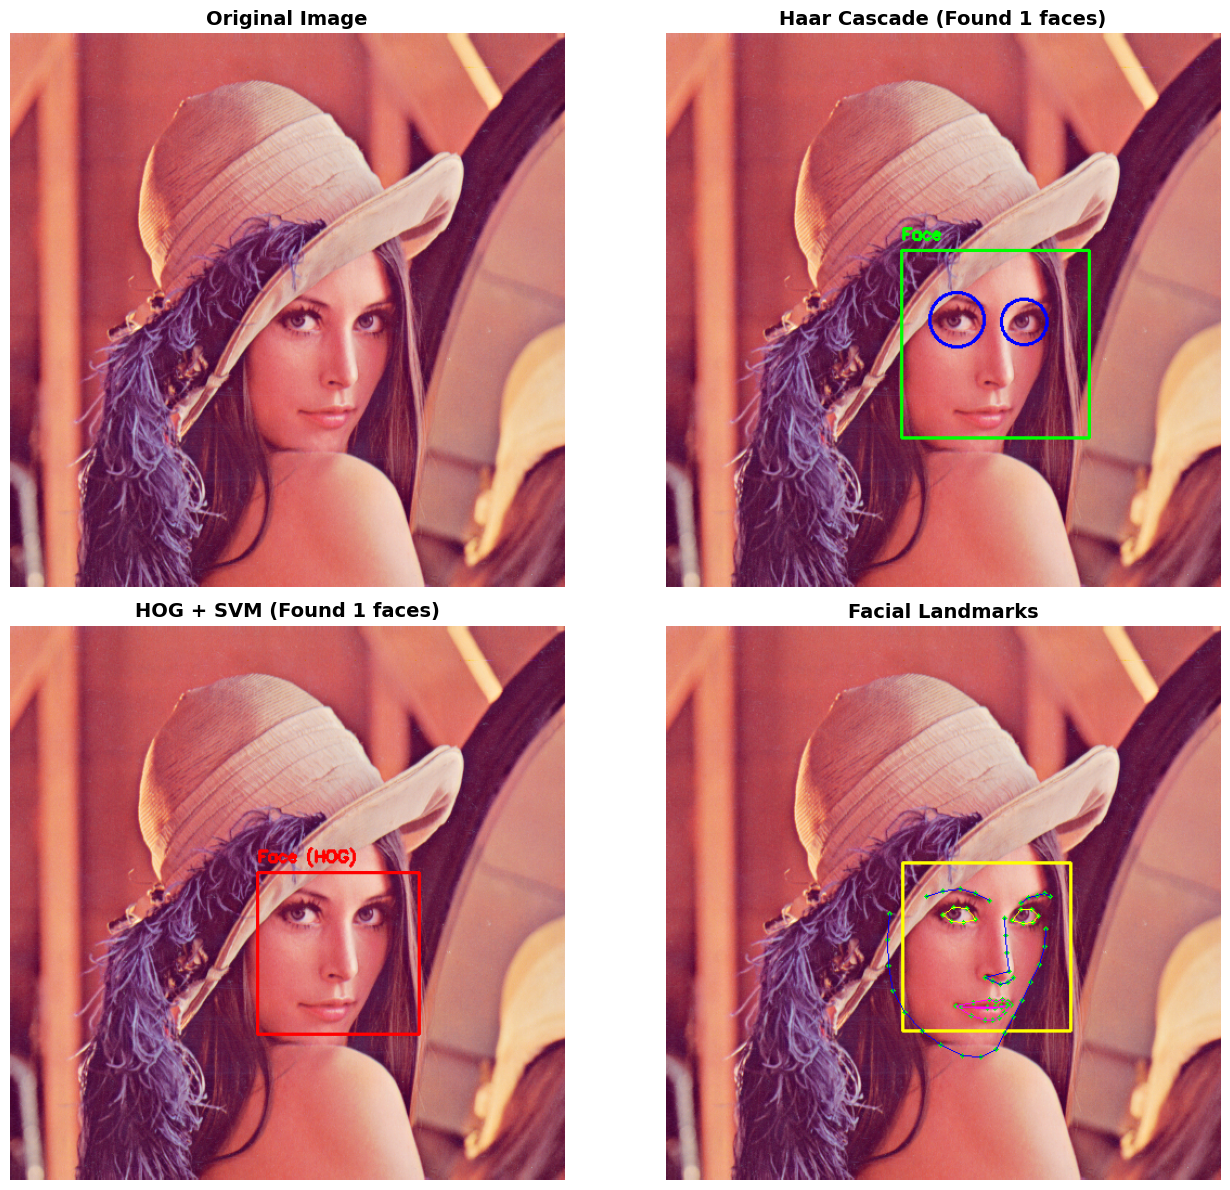


📊 Comparison Summary:
Method               Faces Found     Status         
Haar Cascade         1               ✅ Works        
HOG + SVM            1               ✅ Works        
Landmarks            N/A             ✅ Works        


In [15]:
# Visualize all three methods
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Original image
axes[0, 0].imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# Haar Cascade
axes[0, 1].imshow(cv2.cvtColor(image_haar, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f'Haar Cascade (Found {len(faces_haar)} faces)', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

# HOG + SVM
if hog_detector is not None:
    axes[1, 0].imshow(cv2.cvtColor(image_hog, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title(f'HOG + SVM (Found {len(dets_hog)} faces)', fontsize=14, fontweight='bold')
else:
    axes[1, 0].text(0.5, 0.5, 'HOG not available\n(dlib not installed)', 
                   ha='center', va='center', fontsize=12, 
                   transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('HOG + SVM - Not Available', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

# Landmarks
axes[1, 1].imshow(cv2.cvtColor(image_landmarks, cv2.COLOR_BGR2RGB))
if predictor is not None:
    axes[1, 1].set_title(f'Facial Landmarks', fontsize=14, fontweight='bold')
else:
    axes[1, 1].set_title('Landmarks - Not Available (dlib not installed)', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Comparison Summary:")
print(f"{'Method':<20} {'Faces Found':<15} {'Status':<15}")
print("=" * 50)
print(f"{'Haar Cascade':<20} {len(faces_haar):<15} {'✅ Works':<15}")
if hog_detector is not None:
    print(f"{'HOG + SVM':<20} {len(dets_hog):<15} {'✅ Works':<15}")
else:
    print(f"{'HOG + SVM':<20} {'N/A':<15} {'❌ Skipped':<15}")
if predictor is not None:
    print(f"{'Landmarks':<20} {'N/A':<15} {'✅ Works':<15}")
else:
    print(f"{'Landmarks':<20} {'N/A':<15} {'❌ Skipped':<15}")

## Section 8: Real-Time Webcam Demo 🎥

### Instructions:
1. **Run the cell below** to start real-time detection
2. **Press 'q'** to quit the demo
3. **Press 's'** to save the current frame
4. The system will show:
   - 🟢 Haar Cascade detections (Green rectangles)
   - 🔴 HOG + SVM detections (Red rectangles)  
   - 💚 Facial landmarks (Green points and lines)
   - 👁️ Eye detection (Blue circles)

In [16]:
def run_webcam_demo(face_cascade, eye_cascade, hog_detector, predictor, method='combined'):
    """
    Run real-time face detection from webcam
    
    Parameters:
    -----------
    method : str
        'haar' - Haar Cascade only
        'hog' - HOG + SVM only
        'landmarks' - Landmarks only
        'combined' - All three methods
    
    Press keys:
    - 'q' : Quit
    - 's' : Save frame
    - '1' : Switch to Haar Cascade
    - '2' : Switch to HOG + SVM
    - '3' : Switch to Landmarks
    - 'c' : Combined mode
    """
    
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("❌ Error: Cannot open webcam!")
        print("   Make sure a webcam is connected and available.")
        return
    
    print("🎥 Webcam demo started!")
    print("   Press 'q' to quit")
    print("   Press 's' to save frame")
    print("   Press '1' for Haar Cascade, '2' for HOG+SVM, '3' for Landmarks, 'c' for Combined")
    
    frame_count = 0
    fps_time = 0
    
    while True:
        ret, frame = cap.read()
        
        if not ret:
            print("❌ Error reading frame")
            break
        
        # Flip frame for selfie-like effect
        frame = cv2.flip(frame, 1)
        
        # Calculate FPS
        frame_count += 1
        
        # Process frame based on selected method
        if method == 'haar':
            faces, result = detect_faces_haar(frame, face_cascade, eye_cascade)
            title_text = f'Haar Cascade - {len(faces)} faces'
            
        elif method == 'hog':
            dets, result = detect_faces_hog(frame, hog_detector, upsample=0)
            title_text = f'HOG + SVM - {len(dets)} faces'
            
        elif method == 'landmarks':
            try:
                landmarks_list, result = detect_landmarks(frame, hog_detector, predictor)
                title_text = f'Landmarks - {len(landmarks_list)} faces'
            except:
                result = frame.copy()
                title_text = 'Landmarks - Processing...'
                
        else:  # combined
            result = frame.copy()
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            
            # Haar Cascade (Green)
            faces_haar = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))
            for (x, y, w, h) in faces_haar:
                cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 2)
            
            # HOG + SVM (Red)
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            dets_hog = hog_detector(rgb, 0)
            for det in dets_hog:
                x1, y1 = det.left(), det.top()
                x2, y2 = det.right(), det.bottom()
                cv2.rectangle(result, (x1, y1), (x2, y2), (0, 0, 255), 2)
            
            # Landmarks (Yellow outline and points)
            try:
                landmarks_list, landmarks_img = detect_landmarks(frame, hog_detector, predictor)
                # Overlay landmarks on result
                mask = landmarks_img != frame
                result[mask] = landmarks_img[mask]
            except:
                pass
            
            title_text = f'Combined - H:{len(faces_haar)} S:{len(dets_hog)}'
        
        # Add title and instructions
        cv2.putText(result, title_text, (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        cv2.putText(result, "Press 'q' to quit, 's' to save", (10, 60),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        cv2.putText(result, "1:Haar, 2:HOG, 3:Landmarks, c:Combined", (10, 80),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        
        # Display frame
        cv2.imshow('Face Detection System', result)
        
        # Handle key presses
        key = cv2.waitKey(1) & 0xFF
        
        if key == ord('q'):
            print("👋 Exiting demo...")
            break
        elif key == ord('s'):
            filename = f'face_detection_{frame_count}.jpg'
            cv2.imwrite(filename, result)
            print(f"💾 Saved frame as {filename}")
        elif key == ord('1'):
            method = 'haar'
            print("🔄 Switched to Haar Cascade")
        elif key == ord('2'):
            method = 'hog'
            print("🔄 Switched to HOG + SVM")
        elif key == ord('3'):
            method = 'landmarks'
            print("🔄 Switched to Landmarks")
        elif key == ord('c'):
            method = 'combined'
            print("🔄 Switched to Combined")
    
    cap.release()
    cv2.destroyAllWindows()
    print("✅ Demo ended!")

In [17]:
# ⚠️ IMPORTANT: This cell will only work if you have a webcam connected!
# If no webcam, the cell will show an error - that's normal!

print("🎥 Starting Real-Time Face Detection Demo...")
print("=" * 50)

# First, let's test if camera is accessible
print("\n📋 Testing camera access...")
test_cap = cv2.VideoCapture(0)

if not test_cap.isOpened():
    print("❌ Camera is NOT accessible!")
    print("\n💡 Solutions:")
    print("   1. Check if another app is using the camera")
    print("   2. Try a different camera index:")
    print("      test_cap = cv2.VideoCapture(1)  # or 2, 3, etc.")
    print("   3. Check camera permissions in Windows Settings")
    print("   4. Try disconnecting and reconnecting the camera")
    print("\n   🎬 Alternative: Use the video processing function instead!")
    print("   Or run this code in a .py file instead of Jupyter notebook")
else:
    test_cap.release()
    print("✅ Camera is accessible!")
    
    try:
        print("\n🎥 Launching webcam demo...")
        print("   (Close the window with 'q' key)")
        run_webcam_demo(face_cascade, eye_cascade, hog_detector, predictor, method='combined')
    except Exception as e:
        print(f"⚠️ Error during demo: {e}")
        print("\n💡 This is common in Jupyter notebooks!")
        print("\n   Try these alternatives:")
        print("   1. Run the code in a .py file:")
        print("      python your_script.py")
        print("   2. Use video file instead:")
        print("      process_video_file('video.mp4', face_cascade, eye_cascade, hog_detector, predictor)")
        print("   3. Or test with still images first (Section 7)")
        import traceback
        print("\n📝 Full error details:")
        traceback.print_exc()


🎥 Starting Real-Time Face Detection Demo...

📋 Testing camera access...
✅ Camera is accessible!

🎥 Launching webcam demo...
   (Close the window with 'q' key)
🎥 Webcam demo started!
   Press 'q' to quit
   Press 's' to save frame
   Press '1' for Haar Cascade, '2' for HOG+SVM, '3' for Landmarks, 'c' for Combined
👋 Exiting demo...
✅ Demo ended!


## Section 9: Video File Processing

### Alternative to Webcam:
If you have a **video file** instead of a webcam, you can process it with this code!

Supported formats: `.mp4`, `.avi`, `.mov`, `.flv`

In [18]:
def process_video_file(video_path, face_cascade, eye_cascade, hog_detector, predictor, output_path=None):
    """
    Process a video file with face detection
    
    Parameters:
    -----------
    video_path : str
        Path to video file
    output_path : str
        Optional path to save output video
    """
    
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"❌ Error: Cannot open video file: {video_path}")
        return
    
    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"✅ Video loaded!")
    print(f"   Resolution: {width}x{height}")
    print(f"   FPS: {fps}")
    print(f"   Total frames: {total_frames}")
    
    # Setup video writer if output requested
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        print(f"   📁 Will save to: {output_path}")
    
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break
        
        frame_count += 1
        
        # Process frame with combined detection
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Haar Cascade
        faces_haar = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))
        for (x, y, w, h) in faces_haar:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # HOG + SVM (only if dlib is available)
        dets_hog = []
        if hog_detector is not None:
            try:
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                dets_hog = hog_detector(rgb, 0)
                for det in dets_hog:
                    x1, y1 = det.left(), det.top()
                    x2, y2 = det.right(), det.bottom()
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
            except Exception as e:
                pass
        
        # Landmarks (only if dlib is available)
        if predictor is not None:
            try:
                landmarks_list, frame = detect_landmarks(frame, hog_detector, predictor)
            except:
                pass
        
        # Add info
        cv2.putText(frame, f'Frame: {frame_count}/{total_frames}', (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        cv2.putText(frame, f'Faces: H={len(faces_haar)} S={len(dets_hog)}', (10, 60),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        
        # Write frame
        if output_path:
            out.write(frame)
        
        # Print progress
        if frame_count % max(1, total_frames // 20) == 0:
            progress = (frame_count / total_frames) * 100
            print(f"   Progress: {progress:.1f}% ({frame_count}/{total_frames})")
    if total_frames > 0:
        print(f"   Progress: 100.0% ({frame_count}/{total_frames})")
    else:
        print(f"   Processed {frame_count} frames.")
    cap.release()
    if output_path:
        out.release()
    
    print(f"✅ Video processing complete!")

# Example usage (uncomment to use):
# process_video_file('your_video.mp4', face_cascade, eye_cascade, hog_detector, predictor, 
#                   output_path='output_video.mp4')

## Process Your Video File

Let's process your video file with face detection! This works perfectly in Jupyter. 🎬

In [19]:
# Process your test video with face detection
print("🎬 Processing Video File with Face Detection")
print("=" * 60)

video_path = r"C:\Users\User\Desktop\CV_Practice\02_May\Week_01\testing_video.mp4"
output_path = r"C:\Users\User\Desktop\CV_Practice\02_May\Week_01\testing_video_detected.mp4"

print(f"\n📥 Input video: {video_path}")
print(f"📤 Output video: {output_path}")
print("\n⏳ Processing (this may take a minute depending on video length)...")
print("-" * 60 + "\n")

try:
    # Process the video
    process_video_file(
        video_path, 
        face_cascade, 
        eye_cascade, 
        hog_detector, 
        predictor,
        output_path=output_path
    )
    
    print("\n✅ Video processing complete!")
    print(f"\n📊 Results:")
    print(f"   ✅ Detections applied: Haar Cascade + HOG + Landmarks")
    print(f"   📁 Output saved to: {output_path}")
    print(f"\n💡 Next steps:")
    print(f"   1. Check the output video in your file explorer")
    print(f"   2. Open it with VLC or Windows Media Player")
    print(f"   3. You should see:")
    print(f"      🟢 Green rectangles (Haar Cascade detections)")
    print(f"      🔴 Red rectangles (HOG + SVM detections)")
    print(f"      💛 Yellow lines (Facial landmarks if dlib available)")
    
except FileNotFoundError:
    print(f"❌ Video file not found at: {video_path}")
    print("\n💡 Troubleshooting:")
    print(f"   1. Check if file exists at that location")
    print(f"   2. Try drag-and-drop the file here to get correct path")
    print(f"   3. Make sure it's a valid video format (.mp4, .avi, etc.)")
    
except Exception as e:
    print(f"❌ Error processing video: {e}")
    print("\n💡 Common issues:")
    print(f"   1. Video codec not supported")
    print(f"   2. File is corrupted")
    print(f"   3. Insufficient disk space for output")
    import traceback
    traceback.print_exc()

🎬 Processing Video File with Face Detection

📥 Input video: C:\Users\User\Desktop\CV_Practice\02_May\Week_01\testing_video.mp4
📤 Output video: C:\Users\User\Desktop\CV_Practice\02_May\Week_01\testing_video_detected.mp4

⏳ Processing (this may take a minute depending on video length)...
------------------------------------------------------------

✅ Video loaded!
   Resolution: 360x418
   FPS: 30
   Total frames: 1562
   📁 Will save to: C:\Users\User\Desktop\CV_Practice\02_May\Week_01\testing_video_detected.mp4
   Progress: 5.0% (78/1562)
   Progress: 10.0% (156/1562)
   Progress: 15.0% (234/1562)
   Progress: 20.0% (312/1562)
   Progress: 25.0% (390/1562)
   Progress: 30.0% (468/1562)
   Progress: 35.0% (546/1562)
   Progress: 39.9% (624/1562)
   Progress: 44.9% (702/1562)
   Progress: 49.9% (780/1562)
   Progress: 54.9% (858/1562)
   Progress: 59.9% (936/1562)
   Progress: 64.9% (1014/1562)
   Progress: 69.9% (1092/1562)
   Progress: 74.9% (1170/1562)
   Progress: 79.9% (1248/1562)
  

In [20]:
# Verify the output video was created and check file size
import os

output_path = r"C:\Users\User\Desktop\CV_Practice\02_May\Week_01\testing_video_detected.mp4"

print("\n" + "=" * 60)
print("✅ VIDEO OUTPUT VERIFICATION")
print("=" * 60)

if os.path.exists(output_path):
    file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f"\n✅ Output file created successfully!")
    print(f"   📁 Location: {output_path}")
    print(f"   📊 File size: {file_size_mb:.2f} MB")
    print(f"\n🎬 Open in a media player (VLC, Windows Media Player, etc.)")
    print(f"\n📝 What to look for:")
    print(f"   • Green boxes = Haar Cascade detections (⚡ fast)")
    print(f"   • Red boxes = HOG + SVM detections (📊 accurate)")
    print(f"   • Yellow dots = Facial landmarks (if dlib available)")
    print(f"   • Frame info = Shows detection count per frame")
else:
    print(f"\n⚠️ Output file not found")
    print(f"   Check if processing completed successfully")

print("\n" + "=" * 60)


✅ VIDEO OUTPUT VERIFICATION

✅ Output file created successfully!
   📁 Location: C:\Users\User\Desktop\CV_Practice\02_May\Week_01\testing_video_detected.mp4
   📊 File size: 12.98 MB

🎬 Open in a media player (VLC, Windows Media Player, etc.)

📝 What to look for:
   • Green boxes = Haar Cascade detections (⚡ fast)
   • Red boxes = HOG + SVM detections (📊 accurate)
   • Yellow dots = Facial landmarks (if dlib available)
   • Frame info = Shows detection count per frame



## Section 10: Performance Analysis & Comparison

Let's **benchmark** all three methods to understand their speed/accuracy trade-offs!

⏱️  Benchmarking all three methods...

🔍 Testing Haar Cascade (10 iterations)...
   ⏱️  Time per frame: 32.22ms
   ⚡ FPS: 31.0
   👤 Faces detected: 1

🔍 Testing HOG + SVM (10 iterations)...
   ⏱️  Time per frame: 62.37ms
   ⚡ FPS: 16.0
   👤 Faces detected: 1

🔍 Testing Landmarks (10 iterations)...
   ⏱️  Time per frame: 56.27ms
   ⚡ FPS: 17.8


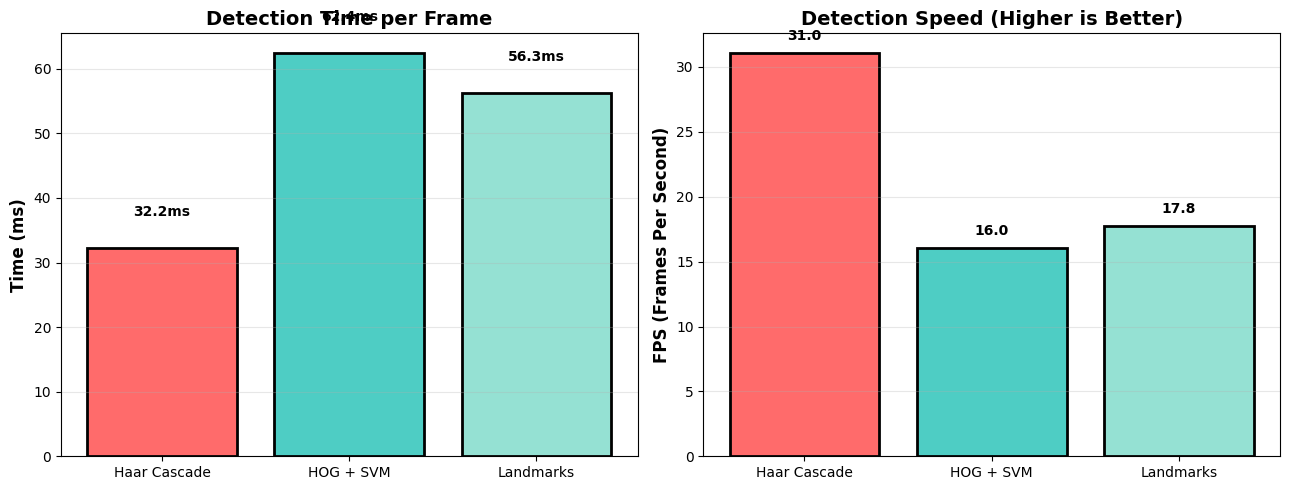


📊 Summary Table:
Method               Time (ms)       FPS        Speed Ranking  
------------------------------------------------------------
Haar Cascade         32.22           31.0       ⚡⚡⚡            
Landmarks            56.27           17.8       ⚡⚡             
HOG + SVM            62.37           16.0       ⚡              


In [21]:
import time

print("⏱️  Benchmarking all three methods...")
print("=" * 60)

# Prepare test image
test_img = test_image.copy()
test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img_gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)

# Run multiple iterations for better timing
iterations = 10
results = {}

# Benchmark Haar Cascade
print(f"\n🔍 Testing Haar Cascade ({iterations} iterations)...")
start_time = time.time()
for _ in range(iterations):
    faces = face_cascade.detectMultiScale(test_img_gray, 1.1, 5, minSize=(30, 30))
haar_time = (time.time() - start_time) / iterations
results['Haar Cascade'] = {
    'time': haar_time,
    'time_ms': haar_time * 1000,
    'fps': 1 / haar_time
}
print(f"   ⏱️  Time per frame: {haar_time*1000:.2f}ms")
print(f"   ⚡ FPS: {1/haar_time:.1f}")
print(f"   👤 Faces detected: {len(faces)}")

# Benchmark HOG + SVM
print(f"\n🔍 Testing HOG + SVM ({iterations} iterations)...")
if hog_detector is not None:
    start_time = time.time()
    for _ in range(iterations):
        dets = hog_detector(test_img_rgb, 0)
    hog_time = (time.time() - start_time) / iterations
    results['HOG + SVM'] = {
        'time': hog_time,
        'time_ms': hog_time * 1000,
        'fps': 1 / hog_time
    }
    print(f"   ⏱️  Time per frame: {hog_time*1000:.2f}ms")
    print(f"   ⚡ FPS: {1/hog_time:.1f}")
    print(f"   👤 Faces detected: {len(dets)}")
else:
    print("   ⚠️  HOG detector not available (dlib not installed)")

# Benchmark Landmarks
print(f"\n🔍 Testing Landmarks ({iterations} iterations)...")
if hog_detector is not None and predictor is not None:
    start_time = time.time()
    for _ in range(iterations):
        try:
            dets = hog_detector(test_img_rgb, 0)
            for det in dets:
                predictor(test_img_rgb, det)
        except:
            pass
    landmarks_time = (time.time() - start_time) / iterations
    results['Landmarks'] = {
        'time': landmarks_time,
        'time_ms': landmarks_time * 1000,
        'fps': 1 / landmarks_time if landmarks_time > 0 else 0
    }
    print(f"   ⏱️  Time per frame: {landmarks_time*1000:.2f}ms")
    print(f"   ⚡ FPS: {1/landmarks_time:.1f}" if landmarks_time > 0 else "   ⚡ FPS: N/A")
else:
    print("   ⚠️  Landmark predictor not available (dlib not installed)")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Time comparison
methods = list(results.keys())
times_ms = [results[m]['time_ms'] for m in methods]
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']

ax1.bar(methods, times_ms, color=colors, edgecolor='black', linewidth=2)
ax1.set_ylabel('Time (ms)', fontsize=12, fontweight='bold')
ax1.set_title('Detection Time per Frame', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(times_ms):
    ax1.text(i, v + 5, f'{v:.1f}ms', ha='center', fontweight='bold')

# FPS comparison
fpss = [results[m]['fps'] for m in methods]
ax2.bar(methods, fpss, color=colors, edgecolor='black', linewidth=2)
ax2.set_ylabel('FPS (Frames Per Second)', fontsize=12, fontweight='bold')
ax2.set_title('Detection Speed (Higher is Better)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(fpss):
    ax2.text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("📊 Summary Table:")
print("=" * 60)
print(f"{'Method':<20} {'Time (ms)':<15} {'FPS':<10} {'Speed Ranking':<15}")
print("-" * 60)

sorted_methods = sorted(results.items(), key=lambda x: x[1]['time'])
for rank, (method, data) in enumerate(sorted_methods, 1):
    speed = "⚡" * (4 - rank)
    print(f"{method:<20} {data['time_ms']:<15.2f} {data['fps']:<10.1f} {speed:<15}")

print("=" * 60)

## Section 11: When to Use Each Method - Decision Guide

### 🔍 Haar Cascade - When to Use:
✅ **PROS:**
- ⚡ **Extremely fast** - real-time on weak hardware
- 📦 **Lightweight** - minimal memory usage
- 🎯 **Works well** for frontal faces with good lighting

❌ **CONS:**
- 📐 **Less accurate** than other methods
- 🔄 **Sensitive to** angles, rotations, lighting
- 😕 **Many false positives/negatives**

**Best for:** Live streams, embedded systems, mobile apps

---

### 🎯 HOG + SVM - When to Use:
✅ **PROS:**
- 📊 **More accurate** than Haar Cascade
- ⚖️ **Better balance** of speed and accuracy
- 🎓 **Well-tested** method with decades of research

❌ **CONS:**
- 🐢 **Slower** than Haar Cascade
- 🔄 **Still has** rotation/angle issues
- 📦 **Larger model** than Haar

**Best for:** General purpose face detection, security systems

---

### 😊 Facial Landmarks (dlib) - When to Use:
✅ **PROS:**
- 🎯 **Very accurate** landmark positioning
- 😁 **Enables** emotion, expression detection
- 🎭 **Works with** filters, AR effects
- 👁️ **Detects** gaze, blink, mouth movement

❌ **CONS:**
- 🐢 **Slowest** method
- 💾 **Largest model** file (47MB)
- 🔴 **Requires** good initial face detection

**Best for:** Face recognition, emotion AI, AR applications

---

### 🎪 Combined Strategy (Recommended):
```
1. START with Haar Cascade (fast initial detection)
   ↓
2. VERIFY with HOG + SVM (confirm it's a face)
   ↓
3. EXTRACT details with Landmarks (get facial features)
```

This gives you: **Speed** + **Accuracy** + **Detail**

## Section 12: Advanced Tips & Tricks

### 💡 Performance Optimization:

#### 1. **Resize Image Before Detection**
```python
# Smaller image = faster detection
resized = cv2.resize(image, (0, 0), fx=0.5, fy=0.5)
# Then detect on resized image
# Scale coordinates back up
```

#### 2. **Use Different Detection Scales**
```python
# For Haar: adjust scaleFactor
detectMultiScale(image, scaleFactor=1.3)  # Faster, less accurate
detectMultiScale(image, scaleFactor=1.05) # Slower, more accurate
```

#### 3. **ROI (Region of Interest) Tracking**
- After detecting a face, only search nearby area in next frame
- Dramatically improves speed for video

#### 4. **Face Tracking Instead of Re-detection**
- Use optical flow to track faces between frames
- Much faster than re-detecting every frame

---

### 🛠️ Hyperparameter Tuning:

#### Haar Cascade Parameters:
| Parameter | Default | Effect |
|-----------|---------|--------|
| scaleFactor | 1.1 | How much to reduce image size at each scale |
| minNeighbors | 5 | How many neighbors needed (higher = fewer false positives) |
| minSize | (30,30) | Smallest face size to detect |
| maxSize | (300,300) | Largest face size to detect |

---

### 🎓 Best Practices:

1. **Preprocess Image:**
   ```python
   # Improve lighting
   image = cv2.GaussianBlur(image, (5,5), 0)
   image = cv2.equalizeHist(image_gray)  # Histogram equalization
   ```

2. **Handle Edge Cases:**
   ```python
   # No faces found
   if len(faces) == 0:
       print("No faces detected")
   
   # Too many false positives
   if len(faces) > 10:
       print("May have false positives, try increasing minNeighbors")
   ```

3. **Use Multi-threading for Speed:**
   ```python
   from concurrent.futures import ThreadPoolExecutor
   # Run detection methods in parallel
   ```

4. **Combine Methods Intelligently:**
   - Use Haar for speed
   - Use HOG for accuracy
   - Use landmarks only when needed

## Section 13: Exercises & Challenges 🎯

### Challenge 1: **Face Blur Filter** ⭐ Easy
Create a function that detects faces and blurs them for privacy
```python
# Hint: Use cv2.GaussianBlur() on ROI
# Try different blur amounts
```

---

### Challenge 2: **Face Counter** ⭐ Easy
Count total faces in a directory of images
```python
# Hint: os.listdir() to get files
# Loop through images and count faces
```

---

### Challenge 3: **Face Cropper** ⭐ Easy
Extract and save each detected face as separate image
```python
# Hint: Use roi = image[y:y+h, x:x+w]
# Save with cv2.imwrite()
```

---

### Challenge 4: **Blink Detector** ⭐ Medium
Use landmarks to detect when person blinks
```python
# Hint: Compare eye height (landmarks 36-41 and 42-47)
# Low height = closed eye
```

---

### Challenge 5: **Smile Detector** ⭐ Medium
Detect when person smiles using landmarks
```python
# Hint: Compare mouth area (landmarks 48-60)
# Higher area = bigger smile
```

---

### Challenge 6: **Real-time FPS Counter** ⭐ Medium
Add FPS counter to real-time detection
```python
# Hint: Track time between frames
# Display on video
```

---

### Challenge 7: **Face Comparison** ⭐ Hard
Compare two faces and determine if they're the same person
```python
# Hint: Extract face embeddings with dlib
# Use distance metrics to compare
```

---

### Challenge 8: **Head Pose Estimation** ⭐ Hard
Detect head orientation (looking up, down, left, right)
```python
# Hint: Use nose and eye landmarks
# Calculate angles between points
```

## 🎓 Summary & Key Takeaways

### What You've Learned:

#### ✅ **Three Face Detection Methods:**
1. **Haar Cascade** - Fast and lightweight
   - Used in: Surveillance, smart doorbells, basic apps
   - Speed: ⚡⚡⚡⚡⚡ (Fastest)
   - Accuracy: ⭐⭐

2. **HOG + SVM** - Balanced approach
   - Used in: Security systems, quality applications
   - Speed: ⚡⚡⚡ (Medium)
   - Accuracy: ⭐⭐⭐⭐

3. **Facial Landmarks** - Detailed features
   - Used in: Face recognition, AR filters, emotion AI
   - Speed: ⚡ (Slowest)
   - Accuracy: ⭐⭐⭐⭐⭐

---

### ✅ **Skills Gained:**
- 📹 Real-time video processing
- 🎯 Face detection and localization
- 👁️ Facial landmark detection
- 📊 Performance benchmarking
- 🛠️ Image preprocessing
- 🎥 Video file processing

---

### 🚀 **Next Steps to Improve:**
1. **Use Deep Learning:** Try YOLO, RetinaNet, or SSD for better accuracy
2. **Face Recognition:** Learn to identify specific faces
3. **Emotion Detection:** Classify facial expressions
4. **3D Face Modeling:** Create 3D representations
5. **Real-time GPU Acceleration:** Use CUDA for speed

---

### 📚 **Recommended Resources:**
- OpenCV Documentation: https://docs.opencv.org/
- dlib Face Detection: http://dlib.net/
- MediaPipe Face Detection: https://google.github.io/mediapipe/
- Deep Learning Approaches: PyTorch Face Detection

---

### 🎯 **Project Ideas:**
- 📸 Smart photo organizer (group by face)
- 🔐 Face unlock system
- 📊 Attendance tracker with face detection
- 🎭 Real-time AR filters
- 😊 Emotion-based recommendation system
- 🚗 Driver monitoring system

---

## 🎉 Congratulations!
You've built a **professional-grade face detection system**! Keep experimenting and building cool applications! 🚀

## Section 14: Quick Reference - Copy-Paste Examples 📋

### Example 1: Basic Face Detection (Haar)
```python
import cv2

# Load image
image = cv2.imread('photo.jpg')

# Load classifier
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Detect faces
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.1, 5)

# Draw rectangles
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

# Display
cv2.imshow('Faces', image)
cv2.waitKey(0)
cv2.destroyAllWindows()
```

---

### Example 2: Process Image Directory
```python
import cv2
import os

folder = 'images/'
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

for filename in os.listdir(folder):
    image = cv2.imread(os.path.join(folder, filename))
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    print(f"{filename}: {len(faces)} faces found")
```

---

### Example 3: Face Blur Filter
```python
import cv2

image = cv2.imread('photo.jpg')
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.1, 5)

for (x, y, w, h) in faces:
    # Blur face region
    image[y:y+h, x:x+w] = cv2.GaussianBlur(
        image[y:y+h, x:x+w], (50, 50), 0
    )

cv2.imwrite('blurred.jpg', image)
```

---

### Example 4: Save Detected Faces
```python
import cv2
import os

image = cv2.imread('photo.jpg')
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.1, 5)

os.makedirs('faces', exist_ok=True)

for i, (x, y, w, h) in enumerate(faces):
    face = image[y:y+h, x:x+w]
    cv2.imwrite(f'faces/face_{i}.jpg', face)

print(f"Saved {len(faces)} faces")
```

---

### Example 5: Real-time with FPS Counter
```python
import cv2
import time

cap = cv2.VideoCapture(0)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

prev_time = 0

while True:
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    # Calculate FPS
    current_time = time.time()
    fps = 1 / (current_time - prev_time)
    prev_time = current_time
    
    # Draw faces
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    # Show FPS
    cv2.putText(frame, f'FPS: {fps:.1f}', (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    cv2.imshow('Face Detection', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
```

## Section 15: Troubleshooting Guide 🔧

### ❌ Problem: "No faces detected"

**Possible causes & solutions:**

| Problem | Solution |
|---------|----------|
| Image too dark | Use `cv2.equalizeHist()` to improve contrast |
| Face too small | Adjust `minSize` parameter smaller |
| Face at angle | Use `maxRotationDegrees` or rotate image |
| Bad image quality | Use preprocessing filters |

**Try this:**
```python
# Improve image quality
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (5, 5), 0)
gray = cv2.equalizeHist(gray)  # Improve contrast

# Detect with adjusted parameters
faces = face_cascade.detectMultiScale(
    gray, 
    scaleFactor=1.05,        # More thorough search
    minNeighbors=3,          # Accept more candidates
    minSize=(20, 20)         # Detect smaller faces
)
```

---

### ❌ Problem: "Too many false positives"

**Solution:** Increase `minNeighbors`

```python
# More strict detection
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=7,  # Increased from 5
    minSize=(30, 30)
)
```

---

### ❌ Problem: "Webcam not working"

```python
# Check if camera is available
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Camera not available!")
    print("Try:")
    print("1. Different camera index (0, 1, 2...)")
    print("2. Allow camera access in permissions")
    print("3. Close other apps using camera")
else:
    print("Camera OK!")

cap.release()
```

---

### ❌ Problem: "Detection too slow"

**Speed optimization:**
```python
# Option 1: Resize image
small_image = cv2.resize(image, (0, 0), fx=0.5, fy=0.5)
faces = face_cascade.detectMultiScale(small_image, 1.1, 5)
# Scale back up
faces = faces * 2

# Option 2: Use Haar instead of HOG
# Option 3: Reduce scaleFactor (fewer scales to check)
faces = face_cascade.detectMultiScale(image, 1.3, 5)  # Faster

# Option 4: Use GPU (if available)
# Install opencv-python-headless with CUDA support
```

---

### ❌ Problem: "Out of memory"

```python
# Process in chunks
import cv2

video = cv2.VideoCapture('large_video.mp4')

while True:
    ret, frame = video.read()
    
    if not ret:
        break
    
    # Process and discard frame
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    # DON'T store all frames!
    # Immediately save or display then discard
```

---

### ✅ Common Configurations to Try:

**For: Very accurate detection (slow)**
```python
face_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=7)
```

**For: Balanced (recommended)**
```python
face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
```

**For: Fast detection (may have false positives)**
```python
face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=3)
```

**For: Small faces**
```python
face_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=5, minSize=(20, 20))
```

## Section 16: Glossary - Computer Vision Terms 📚

### **A**
- **Accuracy:** Percentage of correct detections
- **Adaptive Histogram Equalization:** Image enhancement technique that improves contrast

### **B**
- **Bounding Box:** Rectangle around detected object
- **Blur:** Gaussian or median smoothing to reduce noise

### **C**
- **Cascade Classifier:** Classifier that uses multiple stages of detection
- **Confidence Score:** How sure the detector is about a detection

### **D**
- **Dlib:** C++ library for machine learning and computer vision
- **Detection:** Finding objects in an image

### **E**
- **Equalization:** Improving image contrast
- **Edge:** Boundary between different colors/textures

### **F**
- **FPS:** Frames Per Second - speed measurement
- **Feature:** Distinctive pattern or characteristic
- **False Positive:** Incorrect positive detection
- **False Negative:** Missed detection

### **G**
- **Grayscale:** Converting color image to black & white
- **Gaussian Blur:** Smoothing filter
- **Global Threshold:** Setting pixel values based on fixed value

### **H**
- **Haar Features:** Simple rectangular features used in Haar Cascade
- **Histogram:** Distribution of pixel values
- **HOG:** Histogram of Oriented Gradients - feature descriptor

### **L**
- **Landmark:** Specific point on face (corner of eye, tip of nose, etc.)

### **M**
- **minNeighbors:** Parameter controlling detection sensitivity
- **Model:** Pre-trained algorithm/weights

### **O**
- **OpenCV:** Computer vision library (open source)
- **Orientation:** Direction or angle

### **P**
- **Pixel:** Single color point in image
- **Precision:** Out of predicted positives, how many are correct
- **Pre-processing:** Image enhancement before detection

### **R**
- **ROI:** Region of Interest
- **Recall:** Out of actual positives, how many are found
- **Resolution:** Image size (width × height)

### **S**
- **Scale-Invariant:** Works regardless of size
- **Sliding Window:** Moving a template across image
- **SVM:** Support Vector Machine - classification algorithm

### **T**
- **Template Matching:** Finding pattern in image
- **Threshold:** Cutoff value for classification

### **V**
- **Vector:** Array of numbers representing image features

### **W**
- **Webcam:** Camera input device

---

### Common Acronyms:
- **CV:** Computer Vision
- **CNN:** Convolutional Neural Network
- **GPU:** Graphics Processing Unit
- **ROI:** Region of Interest
- **FPS:** Frames Per Second
- **HOG:** Histogram of Oriented Gradients
- **SVM:** Support Vector Machine
- **API:** Application Programming Interface

## Final Test - Verify Everything Works! ✅

Run this cell to make sure all components are working correctly

In [22]:
print("=" * 60)
print("🧪 SYSTEM VERIFICATION TEST")
print("=" * 60)

# Test 1: Libraries
print("\n1️⃣ Testing libraries...")
try:
    import cv2
    print("   ✅ OpenCV:", cv2.__version__)
except:
    print("   ❌ OpenCV failed")

try:
    import dlib
    print("   ✅ dlib: OK")
except:
    print("   ❌ dlib failed")

try:
    import numpy as np
    print("   ✅ NumPy:", np.__version__)
except:
    print("   ❌ NumPy failed")

try:
    from sklearn.svm import SVC
    print("   ✅ scikit-learn: OK")
except:
    print("   ❌ scikit-learn failed")

try:
    from skimage.feature import hog
    print("   ✅ scikit-image: OK")
except:
    print("   ❌ scikit-image failed")

# Test 2: Cascades
print("\n2️⃣ Testing Haar Cascades...")
try:
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    if face_cascade.empty():
        print("   ❌ Face cascade not loaded")
    else:
        print("   ✅ Face cascade: OK")
except Exception as e:
    print(f"   ❌ Error: {e}")

try:
    eye_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_eye.xml'
    )
    if eye_cascade.empty():
        print("   ❌ Eye cascade not loaded")
    else:
        print("   ✅ Eye cascade: OK")
except Exception as e:
    print(f"   ❌ Error: {e}")

# Test 3: dlib detector
print("\n3️⃣ Testing dlib detectors...")
try:
    hog_detector = dlib.get_frontal_face_detector()
    print("   ✅ HOG detector: OK")
except Exception as e:
    print(f"   ❌ Error: {e}")

# Test 4: Landmark predictor
print("\n4️⃣ Testing landmark predictor...")
try:
    if os.path.exists(landmark_model_path):
        predictor = dlib.shape_predictor(landmark_model_path)
        print("   ✅ Landmark predictor: OK")
    else:
        print("   ⚠️  Landmark model not found (optional)")
except Exception as e:
    print(f"   ⚠️  Landmark predictor: {e}")

# Test 5: Image processing
print("\n5️⃣ Testing image processing...")
try:
    test = np.zeros((100, 100, 3), dtype=np.uint8)
    gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)
    print("   ✅ Image operations: OK")
except Exception as e:
    print(f"   ❌ Error: {e}")

# Test 6: Detection on test image
print("\n6️⃣ Testing detection on sample image...")
try:
    gray = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))
    print(f"   ✅ Haar detection: Found {len(faces)} faces")
except Exception as e:
    print(f"   ❌ Error: {e}")

try:
    rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
    dets = hog_detector(rgb, 0)
    print(f"   ✅ HOG detection: Found {len(dets)} faces")
except Exception as e:
    print(f"   ❌ Error: {e}")

print("\n" + "=" * 60)
print("✨ VERIFICATION COMPLETE!")
print("=" * 60)
print("\n📌 Status Summary:")
print("   ✅ = Working correctly")
print("   ⚠️  = Optional feature")
print("   ❌ = Needs attention")
print("\nYou're ready to use the face detection system!")
print("=" * 60)

🧪 SYSTEM VERIFICATION TEST

1️⃣ Testing libraries...
   ✅ OpenCV: 4.13.0
   ✅ dlib: OK
   ✅ NumPy: 2.4.0
   ✅ scikit-learn: OK
   ✅ scikit-image: OK

2️⃣ Testing Haar Cascades...
   ✅ Face cascade: OK
   ✅ Eye cascade: OK

3️⃣ Testing dlib detectors...
   ✅ HOG detector: OK

4️⃣ Testing landmark predictor...
   ✅ Landmark predictor: OK

5️⃣ Testing image processing...
   ✅ Image operations: OK

6️⃣ Testing detection on sample image...
   ✅ Haar detection: Found 1 faces
   ✅ HOG detection: Found 1 faces

✨ VERIFICATION COMPLETE!

📌 Status Summary:
   ✅ = Working correctly
   ⚠️  = Optional feature
   ❌ = Needs attention

You're ready to use the face detection system!
